# GW Response Tutorial Notebook

In [1]:
import gw_response as gwr
import sys

print("Running on:", sys.version)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


Running on: 3.8.19 (default, Mar 20 2024, 19:58:24) 
[GCC 11.2.0]


In [2]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
import warnings

warnings.filterwarnings("ignore")

GENERATE_TEST_DATA = True

## Module: `constants`

Contains dataclasses for standard physical constants and TDI basis transformations

In [3]:
ps = gwr.PhysicalConstants()
print("Object:", ps)
print("Example (c in m/s):", ps.light_speed)

Object: PhysicalConstants(light_speed=299792458.0, hour=3600.0, day=86400.0, yr=31557600.0, Hubble_over_h=3.24e-18, AU=149597870700.0, cmb_dipole=Array([-0.972,  0.137, -0.191], dtype=float64))
Example (c in m/s): 299792458.0


## Module: `ligo`

Implementation of the LISA detector class and various helper functions for this

In [4]:
from gw_response.ligo import _SITE_GEOMETRIES

In [5]:
LIGOHAN_ARM1   = _SITE_GEOMETRIES['Hanford']['arm1']
LIGOHAN_ARM2   = _SITE_GEOMETRIES['Hanford']['arm2']
LIGOHAN_C      = _SITE_GEOMETRIES['Hanford']['center']


# Can also be accessed with LISA_satellite_positions
ligo_analytical_positions = gwr.LIGO_satellite_positions(
    1, LIGOHAN_C , LIGOHAN_ARM1, LIGOHAN_ARM2, 4.0e3
)

print(
    "LIGO satellite positions shape:",
    ligo_analytical_positions.shape,
    "[time, vector, satellite]",
)

if GENERATE_TEST_DATA:
    np.save(
        "testing/test_data_ligo/ligo_satellite_positions.npy",
        np.array(ligo_analytical_positions),
    )

LIGO satellite positions shape: (1, 3, 2) [time, vector, satellite]


In [6]:
ligo_arms_matrix=gwr.LIGO_arms_matrix(
    1, LIGOHAN_ARM1, LIGOHAN_ARM2, 4.0e3
)

if GENERATE_TEST_DATA:
    np.save(
        "testing/test_data_ligo/ligo_arms_matrix.npy",
        np.array(ligo_arms_matrix),
    )

ligo_arms_matrix.shape

(1, 3, 4)

In [7]:
arm_lengths = jnp.sqrt(jnp.einsum("tij,tij->tj", ligo_arms_matrix, ligo_arms_matrix))
print("Arm lengths:", arm_lengths[0, :])

if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/arm_lengths.npy", np.array(arm_lengths))

Arm lengths: [4000.         4000.00000001 4000.         4000.00000001]


In [8]:
# LISA detector object available to access all these properties
ligo = gwr.LIGO()
frequencies = ligo.frequency_vec(10)
print(frequencies)
GENERATE_TEST_DATA = True
print("LIGO object:", ligo)
# Generate a given frequency grid between lisa.fmin and lisa.fmax
frequencies = ligo.frequency_vec(10)
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/frequencies.npy", np.array(frequencies))
print("Frequencies:\n", frequencies)

# Compute the corresponding k vector (f * arm_length / c)
kl_vector = ligo.klvector(frequencies)
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/kl_vector.npy", np.array(kl_vector))
print("kl vector:\n", kl_vector)

# or the corresponding x vector (2 pi f L / c) for a given frequency grid
x_vector = ligo.x(frequencies)
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/x_vector.npy", np.array(x_vector))
print("x vector:\n", x_vector)

# Easily access satellite positions and detector arms matrix
satellite_positions = ligo.satellite_positions(1)

print("Satellite positions shape:", satellite_positions.shape)
arms_matrix = ligo.detector_arms(1)
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/arms_matrix.npy", np.array(arms_matrix))
print("Arms matrix shape:", arms_matrix.shape)

[1.00000000e+00 2.23111111e+02 4.45222222e+02 6.67333333e+02
 8.89444444e+02 1.11155556e+03 1.33366667e+03 1.55577778e+03
 1.77788889e+03 2.00000000e+03]
LIGO object: LIGO(which_detector='Hanford', name='LIGO Hanford', ps=PhysicalConstants(light_speed=299792458.0, hour=3600.0, day=86400.0, yr=31557600.0, Hubble_over_h=3.24e-18, AU=149597870700.0, cmb_dipole=Array([-0.972,  0.137, -0.191], dtype=float64)), fmin=1.0, fmax=2000.0, armlength=4000.0, res=0.1)
Frequencies:
 [1.00000000e+00 2.23111111e+02 4.45222222e+02 6.67333333e+02
 8.89444444e+02 1.11155556e+03 1.33366667e+03 1.55577778e+03
 1.77788889e+03 2.00000000e+03]
kl vector:
 [1.33425638e-05 2.97687424e-03 5.94040591e-03 8.90393758e-03
 1.18674693e-02 1.48310009e-02 1.77945326e-02 2.07580643e-02
 2.37215959e-02 2.66851276e-02]
x vector:
 [8.38338009e-05 1.87042525e-02 3.73246711e-02 5.59450898e-02
 7.45655084e-02 9.31859271e-02 1.11806346e-01 1.30426764e-01
 1.49047183e-01 1.67667602e-01]
Satellite positions shape: (1, 3, 2)
Arms 

## Module: `noise`

Implementation of the TM and OMS noise functions and projection through TDI

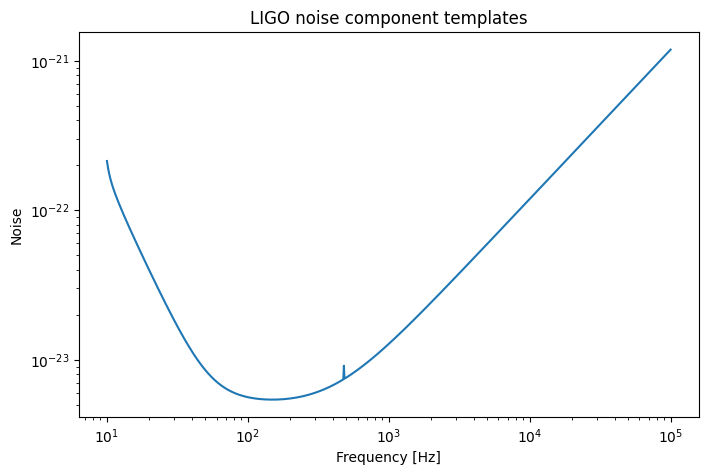

In [9]:
freqs = jnp.logspace(1, 5, 1000)
ligo_noise = gwr.LIGO_noise(
    freqs)  # scales quadratically with acc_param

fig = plt.figure(figsize=(8, 5))
plt.loglog(freqs, ligo_noise, label="ligo noise")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Noise")
plt.title("LIGO noise component templates")

if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/ligo_psd.npy", np.array(ligo_noise))

## Module: `response`

Implements a `Response` class for computing the angular and integrated response in a given detector

In [10]:
# Set up the response object
response = gwr.ResponseLIGO(ps=gwr.PhysicalConstants(), det=gwr.LIGO())

In [12]:
# Angular response
pixel = gwr.Pixel()
theta, phi = pixel.theta_pixel, pixel.phi_pixel
single_link_response = response.get_single_link_response(
    times_in_years=jnp.array([0.0]),
    theta_array=theta,
    phi_array=phi,
    frequency_array=freqs,
    polarization="LR",
)


if GENERATE_TEST_DATA:
    np.save(
        "testing/test_data_ligo/single_link_response_L.npy",
        np.array(single_link_response["L"]),
    )
if GENERATE_TEST_DATA:
    np.save(
        "testing/test_data_ligo/single_link_response_R.npy",
        np.array(single_link_response["R"]),
    )
print(
    "single_link_response shape:",
    single_link_response["L"].shape,
    "[time, freq, arms, pixel]",
)

single_link_response shape: (1, 1000, 4, 768) [time, freq, arms, pixel]


In [13]:
# Compute the full integrated response (still using the TDI_combination specified above)

response.compute_detector(
    times_in_years=jnp.array([0.0]),
    theta_array=theta,
    phi_array=phi,
    frequency_array=freqs,
    polarization="LR",)

print(
    "response shape:",
    response.quadratic_integrated["L"].shape,
    "[time, freq, tdi, tdi]",
)
if GENERATE_TEST_DATA:
    np.save(
        "testing/test_data_ligo/quadratic_response_L.npy",
        np.array(response.quadratic_integrated["L"]),
    )
if GENERATE_TEST_DATA:
    np.save(
        "testing/test_data_ligo/quadratic_response_R.npy",
        np.array(response.quadratic_integrated["R"]))

response shape: (1, 1000, 768) [time, freq, tdi, tdi]


Text(0.5, 1.0, 'Linear response')

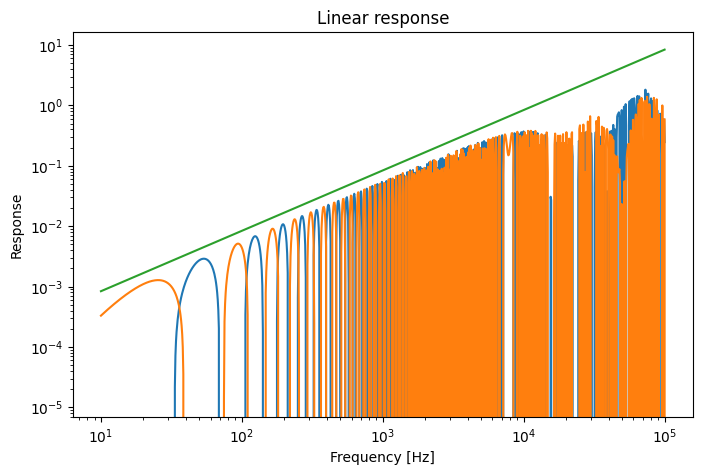

In [14]:
fig = plt.figure(figsize=(8, 5))
plt.loglog(freqs, response.linear_integrand["R"][0, :, 0])
plt.loglog(freqs, response.linear_integrand["L"][0, :, 0])
plt.loglog(freqs,response.det.x(freqs) )
plt.xlabel("Frequency [Hz]")
plt.ylabel("Response")
plt.title("Linear response")

In [15]:
# Compute the full integrated response in AET basis 
response.compute_detector(
    times_in_years=jnp.array([0.0]),
    theta_array=theta,
    phi_array=phi,
    frequency_array=freqs,
    polarization="LR",
)
print(
    "response shape:",
    response.linear_integrand["L"].shape,
    "[time, freq, tdi, tdi]",
)

if GENERATE_TEST_DATA:
    np.save(
        "testing/test_data_ligo/linear_integrand_L.npy",
        np.array(response.linear_integrand["L"]),
    )
if GENERATE_TEST_DATA:
    np.save(
        "testing/test_data_ligo/linear_integrand_R.npy",
        np.array(response.linear_integrand["R"]),
    )



response shape: (1, 1000, 768) [time, freq, tdi, tdi]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 1.0, 'Linear response')

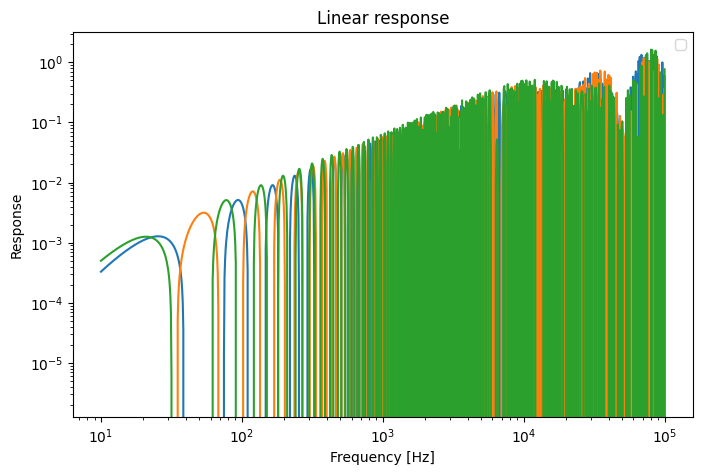

In [16]:
fig = plt.figure(figsize=(8, 5))
for i in range(3):
    plt.loglog(freqs, response.linear_integrand["L"][0, :, i])
plt.legend()
plt.xlabel("Frequency [Hz]")
plt.ylabel("Response")
plt.title("Linear response")

Text(0.5, 1.0, 'Integrand')

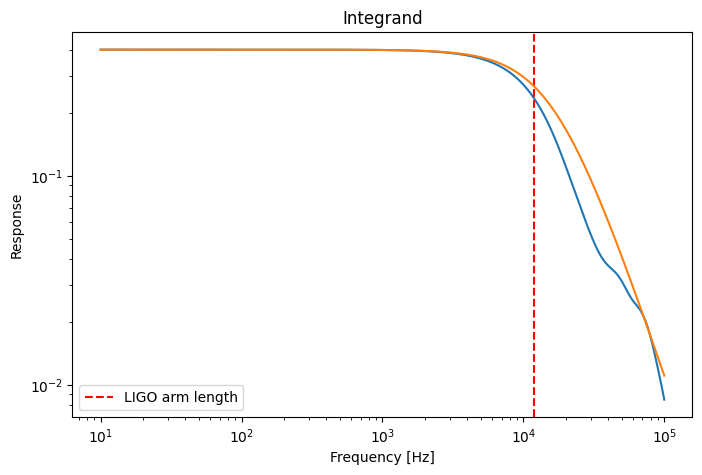

In [18]:
fig = plt.figure(figsize=(8, 5))
plt.loglog(freqs, np.mean(response.quadratic_integrand["R"][0, :, :],axis=-1)/response.det.x(freqs)**2)
#plt.loglog(freqs,response.det.x(freqs)**2 )
plt.axvline(3e8/(2*np.pi*4e3), color="red", linestyle="--", label="LIGO arm length")
plt.loglog(freqs,2/5*1/(1 + .5 * response.det.x(freqs)**2))
plt.legend()
plt.xlabel("Frequency [Hz]")
plt.ylabel("Response")
plt.title("Integrand")

## Module: `single_link`

Implementation of the various helper functions to compute the single link response

In [55]:
# Compute a unit vector in the direction of theta, phi
unit_vector = gwr.unit_vec(theta, phi)
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/unit_vector.npy", np.array(unit_vector))
print("unit_vector shape:", unit_vector.shape, "[xyz, pixel]")

unit_vector shape: (3, 768) [xyz, pixel]


In [56]:
# Complete an orthogonal basis for a given unit vector along theta, phi
u, v = gwr.uv_analytical(theta, phi)
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/u.npy", np.array(u))
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/v.npy", np.array(v))
print("u shape:", u.shape, "[pixel, xyz]")
print("v shape:", v.shape, "[pixel, xyz]")
# These can be used to compute polarization vectors
e1, e2 = gwr.polarization_vectors(u, v)
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/e1.npy", np.array(e1))
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/e2.npy", np.array(e2))
print("e1 shape:", e1.shape, "[pixel, xyz]")
print("e2 shape:", e2.shape, "[pixel, xyz]")
# Or polarisation tensors in some basis
e1p, e1c = gwr.polarization_tensors_PC(u, v)
e1L, e1R = gwr.polarization_tensors_LR(u, v)
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/e1p.npy", np.array(e1p))
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/e1c.npy", np.array(e1c))
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/e1L.npy", np.array(e1L))
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/e1R.npy", np.array(e1R))
print("e1p shape:", e1p.shape, "[pixel, xyz, xyz]")
print("e1c shape:", e1c.shape, "[pixel, xyz, xyz]")
print("e1L shape:", e1L.shape, "[pixel, xyz, xyz]")
print("e1R shape:", e1R.shape, "[pixel, xyz, xyz]")

u shape: (768, 3) [pixel, xyz]
v shape: (768, 3) [pixel, xyz]
e1 shape: (768, 3) [pixel, xyz]
e2 shape: (768, 3) [pixel, xyz]
e1p shape: (768, 3, 3) [pixel, xyz, xyz]
e1c shape: (768, 3, 3) [pixel, xyz, xyz]
e1L shape: (768, 3, 3) [pixel, xyz, xyz]
e1R shape: (768, 3, 3) [pixel, xyz, xyz]


In [57]:
# There are a set of functions to compute the various quantities in the response
xi_k = gwr.xi_k_no_G(
    unit_wavevector=unit_vector,
    x_vector=ligo.x(freqs),
    arms_mat_rescaled=ligo.detector_arms(0.0) / ligo.armlength,
)
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/xi_k.npy", np.array(xi_k))
print("xi_k shape:", xi_k.shape, "[time, freq, arms, pixel]")

xi_k shape: (1, 1000, 4, 768) [time, freq, arms, pixel]


In [124]:
import unittest

def test_position_exp():
    ligo = gwr.LIGO()
    freqs = jnp.logspace(1, 5, 1000)
    pixel = gwr.Pixel()
    #print(pixel)
    theta, phi = pixel.theta_pixel, pixel.phi_pixel
    unit_vector = gwr.unit_vec(theta, phi)
    #print(unit_vector)
    sat_positions = ligo.satellite_positions(0.0)[0]
    #print(sat_positions)
    p1, p2, p3 = sat_positions[:, 0], sat_positions[:, 1], sat_positions[:, 2]
    sp1, sp2, sp3 = gwr.shift_to_center(p1, p2, p3)
    #print(sp1, sp2, sp3)

    position_exp = gwr.position_exponential(
        positions_detector_frame=jnp.array([[sp1, sp2, sp3]]) / ligo.armlength,
        unit_wavevector=unit_vector,
        x_vector=ligo.x(freqs),
    )

    save_arr = np.load("/home/zaldivar/Documents/Androniki/phd/LIGO/GW_response/testing/test_data_ligo/position_exp.npy")
    
    return jnp.sum(jnp.abs(position_exp - save_arr))

In [126]:
sat_positions = ligo.satellite_positions(0.0)[0]
p1, p2, p3 = sat_positions[:, 0], sat_positions[:, 1], sat_positions[:, 2]
sp1, sp2, sp3 = gwr.shift_to_center(p1, p2, p3)


# Or the exponential of the position
position_exp = gwr.position_exponential(
    positions_detector_frame=jnp.array([[sp1, sp2, sp3]]) / ligo.armlength,
    unit_wavevector=unit_vector,
    x_vector=ligo.x(freqs),
)
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/position_exp.npy", np.array(position_exp))
print("position_exp shape:", position_exp.shape, "[time, freq, arms, pixel]")

# Or a geometrical factor
geomtrical_factor = gwr.geometrical_factor(
    arms_matrix=ligo.detector_arms(0.0) / ligo.armlength,
    polarization_tensor=e1L,
)
print("geometrical_factor shape:", geomtrical_factor.shape, "[time, arms, pixel]")
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/geometrical_factor.npy", np.array(geomtrical_factor))

# Or a different version of xi_k
xi_k_Avec = gwr.xi_k_Avec_func(
    arms_matrix_rescaled=ligo.detector_arms(0.0) / ligo.armlength,
    unit_wavevector=unit_vector,
    x_vector=ligo.x(freqs),
    geometrical=geomtrical_factor,
)
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/xi_k_Avec.npy", np.array(xi_k_Avec))
print("xi_k_Avec shape:", xi_k_Avec.shape, "[time, freq, arms, pixel]")

position_exp shape: (1, 1000, 3, 768) [time, freq, arms, pixel]
geometrical_factor shape: (1, 4, 768) [time, arms, pixel]
xi_k_Avec shape: (1, 1000, 4, 768) [time, freq, arms, pixel]


single_link_response shape: (1, 1000, 4, 768) [time, freq, arms, pixel]


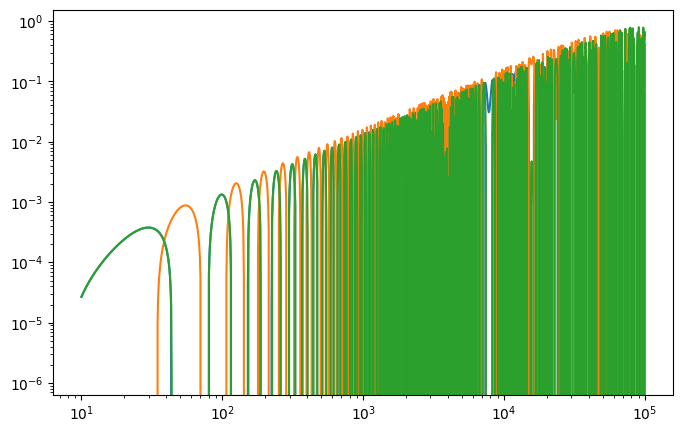

(1, 1000, 4, 768)

In [84]:
# With these we can compute the single link response
geomtrical_factor = gwr.geometrical_factor(
    arms_matrix=ligo.detector_arms(0.0) / ligo.armlength,
    polarization_tensor=e1L,
)
xi_k_Avec = gwr.xi_k_Avec_func(
    arms_matrix_rescaled=ligo.detector_arms(0.0) / ligo.armlength,
    unit_wavevector=unit_vector,
    x_vector=ligo.x(freqs),
    geometrical=geomtrical_factor,
)
single_link_response = gwr.single_link_response(
    positions=ligo.satellite_positions(0.0) / ligo.armlength,
    arms_matrix_rescaled=ligo.detector_arms(0.0) / ligo.armlength,
    wavevector=unit_vector,
    x_vector=ligo.x(freqs),
    xi_k_Avec=xi_k_Avec,
)
if GENERATE_TEST_DATA:
    np.save(
        "testing/test_data_ligo/single_link_response.npy",
        np.array(single_link_response),
    )
print(
    "single_link_response shape:",
    single_link_response.shape,
    "[time, freq, arms, pixel]",
)
fig = plt.figure(figsize=(8, 5))
for i in range(3):
    plt.loglog(freqs, single_link_response[0, :, i, 0])
plt.show()
single_link_response.shape

## Module `utils`

Implements a few helper functions relevant to e.g. the pixelisation of the sky and computing complex exponentials

Number of pixels: 768
theta shape: (768,)
phi shape: (768,)
angular map shape: (768, 2)


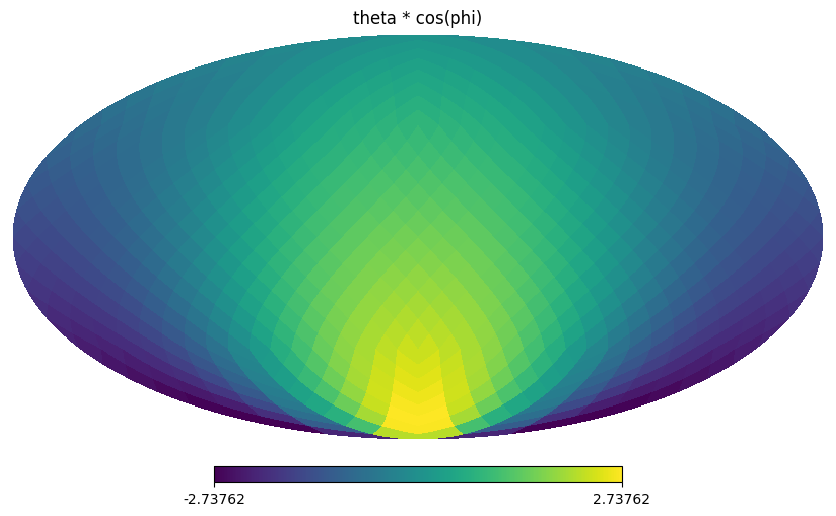

In [61]:
# Pixel class
pixel_class = gwr.Pixel(NSIDE=8)
print("Number of pixels:", pixel_class.NPIX)
print("theta shape:", pixel_class.theta_pixel.shape)
print("phi shape:", pixel_class.phi_pixel.shape)
print("angular map shape:", pixel_class.angular_map.shape)
hp.mollview(
    pixel_class.theta_pixel * jnp.cos(pixel_class.phi_pixel),
    title="theta * cos(phi)",
)
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/pixel_theta.npy", np.array(pixel_class.theta_pixel))
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/pixel_phi.npy", np.array(pixel_class.phi_pixel))
if GENERATE_TEST_DATA:
    np.save(
        "testing/test_data_ligo/pixel_angular_map.npy",
        np.array(pixel_class.angular_map),
    )

Number of pixels: 3072
theta shape: (3072,)
phi shape: (3072,)
angular map shape: (3072, 2)


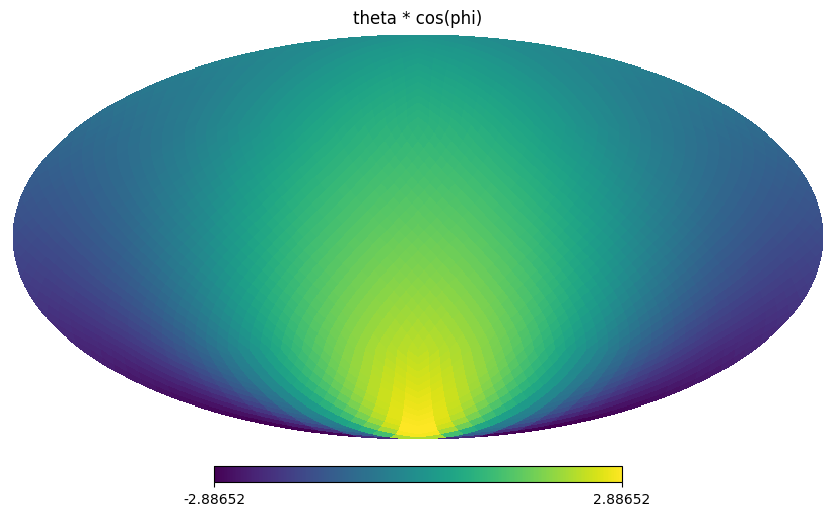

In [62]:
# Can also change the value of NSIDE dynamically
pixel_class.change_NSIDE(NSIDE=16)
print("Number of pixels:", pixel_class.NPIX)
print("theta shape:", pixel_class.theta_pixel.shape)
print("phi shape:", pixel_class.phi_pixel.shape)
print("angular map shape:", pixel_class.angular_map.shape)
hp.mollview(
    pixel_class.theta_pixel * jnp.cos(pixel_class.phi_pixel),
    title="theta * cos(phi)",
)
if GENERATE_TEST_DATA:
    np.save(
        "testing/test_data_ligo/pixel_theta_16.npy",
        np.array(pixel_class.theta_pixel),
    )
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/pixel_phi_16.npy", np.array(pixel_class.phi_pixel))
if GENERATE_TEST_DATA:
    np.save(
        "testing/test_data_ligo/pixel_angular_map_16.npy",
        np.array(pixel_class.angular_map),
    )

In [63]:
# Some helper functions to compute e.g. the arms length exponential
arm_length_exp = gwr.arm_length_exponential(
    arms_matrix_rescaled=ligo.detector_arms(0.0) / ligo.armlength,
    x_vector=ligo.x(freqs),
)
print("arm_length_exp shape:", arm_length_exp.shape, "[time, freq, arms]")
if GENERATE_TEST_DATA:
    np.save("testing/test_data_ligo/arm_length_exp.npy", np.array(arm_length_exp))

# Or shift a set of positions to the centre
sp1, sp2, sp3 = gwr.shift_to_center(p1, p2, p3)
print("New centre of mass (~[0, 0, 0]):", sp1 + sp2 + sp3)

arm_length_exp shape: (1, 1000, 4) [time, freq, arms]
New centre of mass (~[0, 0, 0]): [-3.59477781e-10 -1.70985004e-10  7.68977770e-10]
